In [3]:
# %load run.py
import drive.MyDrive
import dataset
import model
from torch.utils.data import dataloader
import torch.nn as nn
import torch.optim as optim
import torch
import utils

# 初始化数据集，数据加载器， 模型， 损失函数， 优化器


train_dataset = dataset.ChloDataset()
train_dataloader = dataloader.DataLoader(train_dataset, batch_size=32, shuffle=True)
partial_unet = model.PUNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(partial_unet.parameters())
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
partial_unet = partial_unet.to(device)
print("device:", device)

ModuleNotFoundError: ignored

In [1]:
import drive

ModuleNotFoundError: ignored

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 开始训练
for epoch in range(100):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(train_dataloader, 0):

        # get the inputs; data is a list of [inputs, labels]
        inputs, missing, labels = data[0], data[1], data[2]

        # 给输入施加一个mask,施加在三天的chlo-anomaly上
        mask = utils.get_mask(train_dataset)
        inputs_masked = inputs * mask
        missing_masked = missing * mask

        # 将tensor移动到gpu上
        inputs_masked = inputs_masked.to(device)
        missing_masked = missing_masked.to(device)
        labels = labels.to(device)
        missing = missing.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = partial_unet(inputs_masked.float(), missing_masked.float())
        # 损失函数不计算missed
        loss = criterion(outputs * missing[:, 1], labels * missing[:, 1])
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 20 == 19:    # print every 200 mini-batches
            print('[%d, %5d] loss: %.5f' %
                  (epoch + 1, i + 1, running_loss))
            running_loss = 0.0

print('Finished Training')

[1,    20] loss: 0.53030
[2,    20] loss: 0.61020
[3,    20] loss: 0.62078
[4,    20] loss: 0.58174
[5,    20] loss: 0.64085
[6,    20] loss: 0.54798
[7,    20] loss: 0.57938
[8,    20] loss: 0.56527
[9,    20] loss: 0.62413
[10,    20] loss: 0.46678
[11,    20] loss: 0.56253
[12,    20] loss: 0.62002
[13,    20] loss: 0.55800
[14,    20] loss: 0.47974
[15,    20] loss: 0.48892
[16,    20] loss: 0.50515
[17,    20] loss: 0.58820
[18,    20] loss: 0.61777
[19,    20] loss: 0.51034
[20,    20] loss: 0.51149
[21,    20] loss: 0.60132
[22,    20] loss: 0.52155
[23,    20] loss: 0.58191
[24,    20] loss: 0.61352
[25,    20] loss: 0.52484
[26,    20] loss: 0.54900
[27,    20] loss: 0.49169
[28,    20] loss: 0.50603
[29,    20] loss: 0.47781
[30,    20] loss: 0.58424
[31,    20] loss: 0.55268
[32,    20] loss: 0.48646
[33,    20] loss: 0.45041
[34,    20] loss: 0.44208
[35,    20] loss: 0.60360
[36,    20] loss: 0.53552
[37,    20] loss: 0.51901
[38,    20] loss: 0.56135
[39,    20] loss: 0.5

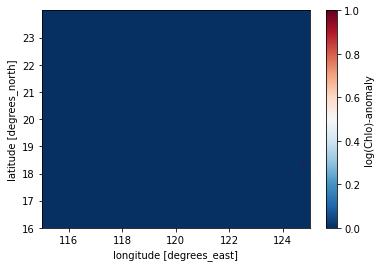

In [ ]:
utils.show(missing_masked[23][1])

In [ ]:
train_dataset.chlo_data.CHL1_mean.std()

<xarray.DataArray 'CHL1_mean' ()>
array(0.37257606)

In [ ]:
def get_normalized(x):
    x_normalized = (x - x.mean()) / x.std()
    return x_normalized

In [ ]:
get_normalized(train_dataset.chlo_data.CHL1_mean).std()

<xarray.DataArray 'CHL1_mean' ()>
array(1.01893397)

In [ ]:
mask.shape

(8, 192, 240)

In [ ]:
inputs.shape

torch.Size([32, 8, 192, 240])

In [ ]:
missing.shape

torch.Size([32, 8, 192, 240])

In [ ]:
(inputs * mask).shape


torch.Size([32, 8, 192, 240])

In [ ]:
c = inputs[:,1:]

In [ ]:
c.shape

torch.Size([32, 7, 192, 240])

In [ ]:
(c * mask).shape

ValueError: operands could not be broadcast together with shapes (32,7,192,240) (8,192,240) 

In [ ]:
utils.show(train_dataset[1][1])

AttributeError: 'numpy.ndarray' object has no attribute 'detach'